# FIAP TECH CHALLENGE 1 - GRUPO SSP

## 6. MODELO PREDITIVO - RANDOM FOREST

Random Forest é um algoritmo de ensemble que combina múltiplas árvores de decisão para melhorar a precisão e reduzir overfitting.

In [1]:
from pathlib import Path

BASE_PATH = Path.cwd().resolve().parent.parent
print(f"Base path: {BASE_PATH.absolute()}")

Base path: /Users/matias/Projetos/fiap/tech-challenge-1


In [2]:
import pandas as pd
import numpy as np

df = pd.read_parquet(BASE_PATH / "data" / "processed" / "df_preprocessed.parquet")

print(f"Shape do dataset: {df.shape}")
print(f"\nColunas: {df.columns.tolist()}")

Shape do dataset: (57022, 38)

Colunas: ['AG_AMEACA', 'AG_CORTE', 'AG_ENFOR', 'AG_ENVEN', 'AG_FOGO', 'AG_FORCA', 'AG_OBJETO', 'AG_OUTROS', 'AG_QUENTE', 'AUTOR_ALCO', 'AUTOR_SEXO', 'CICL_VID', 'CS_RACA', 'DEF_TRANS', 'IDENT_GEN', 'ORIENT_SEX', 'OUT_VEZES', 'SG_UF', 'SIT_CONJUG', 'VIOL_FINAN', 'VIOL_FISIC', 'VIOL_INFAN', 'VIOL_LEGAL', 'VIOL_NEGLI', 'VIOL_OUTR', 'VIOL_PSICO', 'VIOL_SEXU', 'VIOL_TORT', 'VIOL_TRAF', 'DIA_SEMANA_OCOR', 'MES_OCOR', 'REL_PARCEIRO_INTIMO', 'REL_FAMILIAR', 'REL_CONHECIDO', 'REL_INSTITUCIONAL', 'REL_OUTROS_FLAG', 'ESCOLARIDADE', 'CIRC_LESAO_FAMILIA']


Distribuição da variável target (OUT_VEZES):
OUT_VEZES
1.0    30277
0.0    26745
Name: count, dtype: int64

Proporção:
OUT_VEZES
1.0    0.530971
0.0    0.469029
Name: proportion, dtype: float64


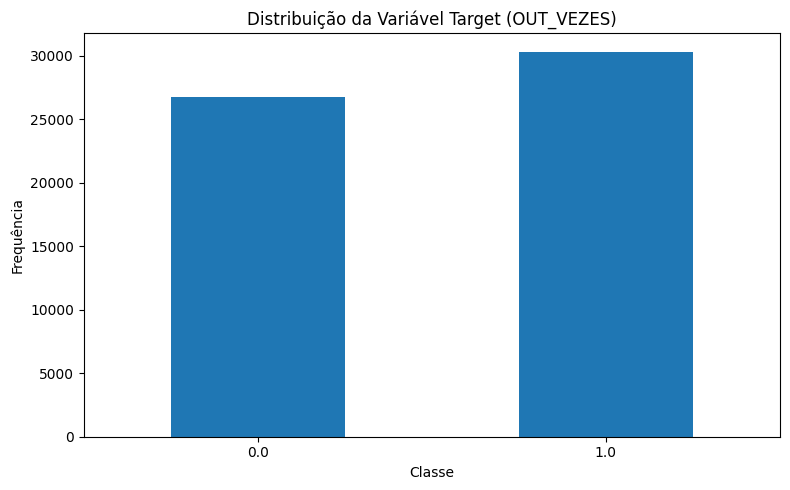

In [3]:
print("Distribuição da variável target (OUT_VEZES):")
print(df['OUT_VEZES'].value_counts())
print(f"\nProporção:")
print(df['OUT_VEZES'].value_counts(normalize=True))

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
df['OUT_VEZES'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Distribuição da Variável Target (OUT_VEZES)')
ax.set_xlabel('Classe')
ax.set_ylabel('Frequência')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=['OUT_VEZES'])
y = df['OUT_VEZES']

print("Preparando os dados...")
print(f"Features iniciais: {X.shape[1]}")

X_encoded = X.copy()
label_encoders = {}

print("\nAplicando LabelEncoder em todas as colunas categóricas...")
for col in X_encoded.columns:
    col_data = X_encoded[col].astype(str).replace('nan', np.nan)
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(col_data)
    label_encoders[col] = le
    
    print(f"  {col}: {len(le.classes_)} categorias únicas")

print("\nVerificando valores faltantes...")
missing_count = X_encoded.isna().sum().sum()
if missing_count > 0:
    print(f"  Encontrados {missing_count} valores faltantes")
    for col in X_encoded.columns:
        mode_value = X_encoded[col].mode()[0] if len(X_encoded[col].mode()) > 0 else 0
        X_encoded[col] = X_encoded[col].fillna(mode_value)
    print("  Valores faltantes tratados")
else:
    print("  Nenhum valor faltante encontrado")

print("\nEncoding da variável target...")
if y.dtype == 'object':
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y.astype(str))
    print(f"  Classes originais: {le_target.classes_}")
    print(f"  Classes codificadas: {np.unique(y_encoded)}")
    y = y_encoded
else:
    print(f"  Target já é numérica: {np.unique(y)}")

print(f"\nDataset preparado:")
print(f"  Features (X_encoded): {X_encoded.shape}")
print(f"  Target (y): {y.shape}")
print(f"  Tipo de dados: {X_encoded.dtypes.unique()}")

Preparando os dados...
Features iniciais: 37

Aplicando LabelEncoder em todas as colunas categóricas...
  AG_AMEACA: 2 categorias únicas
  AG_CORTE: 2 categorias únicas
  AG_ENFOR: 2 categorias únicas
  AG_ENVEN: 2 categorias únicas
  AG_FOGO: 2 categorias únicas
  AG_FORCA: 2 categorias únicas
  AG_OBJETO: 2 categorias únicas
  AG_OUTROS: 2 categorias únicas
  AG_QUENTE: 2 categorias únicas
  AUTOR_ALCO: 2 categorias únicas
  AUTOR_SEXO: 4 categorias únicas
  CICL_VID: 6 categorias únicas
  CS_RACA: 6 categorias únicas
  DEF_TRANS: 2 categorias únicas
  IDENT_GEN: 5 categorias únicas
  ORIENT_SEX: 5 categorias únicas
  SG_UF: 27 categorias únicas
  SIT_CONJUG: 5 categorias únicas
  VIOL_FINAN: 2 categorias únicas
  VIOL_FISIC: 2 categorias únicas
  VIOL_INFAN: 2 categorias únicas
  VIOL_LEGAL: 2 categorias únicas
  VIOL_NEGLI: 2 categorias únicas
  VIOL_OUTR: 2 categorias únicas
  VIOL_PSICO: 2 categorias únicas
  VIOL_SEXU: 2 categorias únicas
  VIOL_TORT: 2 categorias únicas
  VIOL_

DIVISÃO DOS DADOS:
  Treino: 39915 amostras (70.0%)
  Teste: 17107 amostras (30.0%)

Distribuição da target no conjunto de TREINO:
  Classe 0.0: 0.4690 (46.90%)
  Classe 1.0: 0.5310 (53.10%)

Distribuição da target no conjunto de TESTE:
  Classe 0.0: 0.4690 (46.90%)
  Classe 1.0: 0.5310 (53.10%)


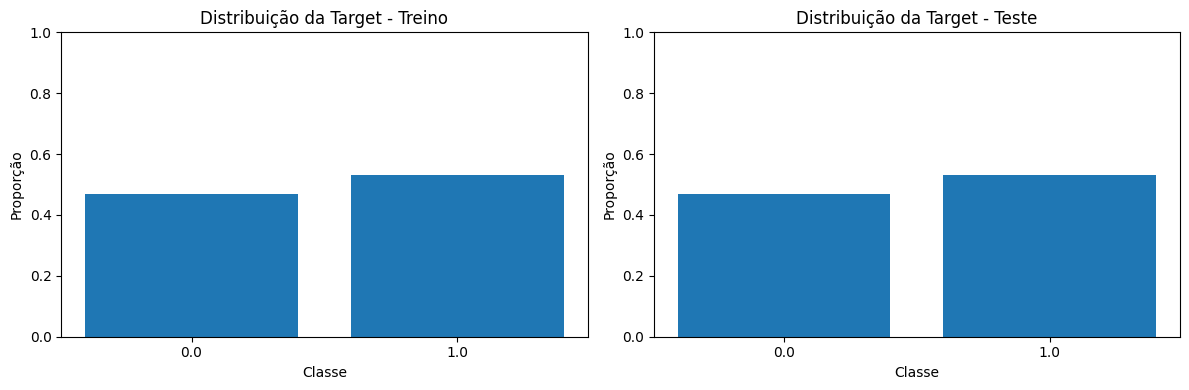

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print("DIVISÃO DOS DADOS:")
print(f"  Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"  Teste: {X_test.shape[0]} amostras ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"\nDistribuição da target no conjunto de TREINO:")
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
for classe, prop in train_dist.items():
    print(f"  Classe {classe}: {prop:.4f} ({prop*100:.2f}%)")

print(f"\nDistribuição da target no conjunto de TESTE:")
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
for classe, prop in test_dist.items():
    print(f"  Classe {classe}: {prop:.4f} ({prop*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(train_dist.index.astype(str), train_dist.values)
axes[0].set_title('Distribuição da Target - Treino')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Proporção')
axes[0].set_ylim([0, 1])

axes[1].bar(test_dist.index.astype(str), test_dist.values)
axes[1].set_title('Distribuição da Target - Teste')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Proporção')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [6]:
print("Verificando qualidade dos dados...")

print(f"  Valores infinitos em X_train: {np.isinf(X_train.values).sum()}")
print(f"  Valores infinitos em X_test: {np.isinf(X_test.values).sum()}")

variances = X_train.var()
zero_var_cols = variances[variances == 0].index.tolist()
if zero_var_cols:
    print(f"  Colunas com variância zero: {zero_var_cols}")
    X_train = X_train.drop(columns=zero_var_cols)
    X_test = X_test.drop(columns=zero_var_cols)
    print(f"  Colunas removidas. Novo shape: {X_train.shape}")

Verificando qualidade dos dados...
  Valores infinitos em X_train: 0
  Valores infinitos em X_test: 0


In [7]:
from sklearn.preprocessing import StandardScaler

print("Normalizando os dados...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Dados normalizados!")
print(f"  Média das features (treino): {X_train_scaled.mean():.6f}")
print(f"  Desvio padrão (treino): {X_train_scaled.std():.6f}")

Normalizando os dados...
Dados normalizados!
  Média das features (treino): 0.000000
  Desvio padrão (treino): 1.000000


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Treinando modelo Random Forest inicial...")
print("=" * 60)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("MÉTRICAS DO MODELO:")
print(f"  Acurácia:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precisão:  {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

if len(np.unique(y_test)) == 2:
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        print(f"  ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)")
    except:
        pass

Treinando modelo Random Forest inicial...
MÉTRICAS DO MODELO:
  Acurácia:  0.7037 (70.37%)
  Precisão:  0.7033 (70.33%)
  Recall:    0.7037 (70.37%)
  F1-Score:  0.7030 (70.30%)
  ROC-AUC:   0.7639 (76.39%)



MATRIZ DE CONFUSÃO

 [[5258 2766]
 [2303 6780]]

  Verdadeiros Negativos (TN): 5258
  Falsos Positivos (FP):       2766
  Falsos Negativos (FN):       2303
  Verdadeiros Positivos (TP):  6780


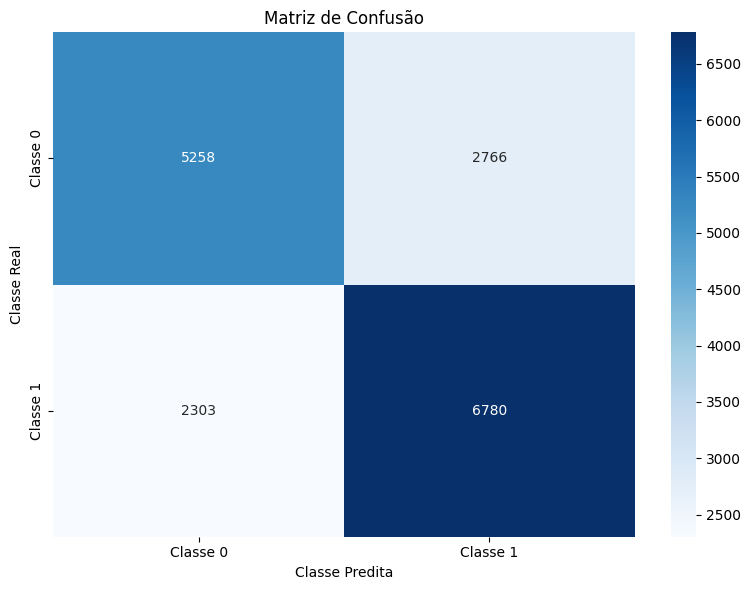


RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

         0.0       0.70      0.66      0.67      8024
         1.0       0.71      0.75      0.73      9083

    accuracy                           0.70     17107
   macro avg       0.70      0.70      0.70     17107
weighted avg       0.70      0.70      0.70     17107



In [9]:
print("\n" + "=" * 60)
print("MATRIZ DE CONFUSÃO")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)
print("\n", cm)

tn, fp, fn, tp = cm.ravel()
print(f"\n  Verdadeiros Negativos (TN): {tn}")
print(f"  Falsos Positivos (FP):       {fp}")
print(f"  Falsos Negativos (FN):       {fn}")
print(f"  Verdadeiros Positivos (TP):  {tp}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Classe 0', 'Classe 1'], 
            yticklabels=['Classe 0', 'Classe 1'])
plt.title('Matriz de Confusão')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("=" * 60)
print(classification_report(y_test, y_pred))

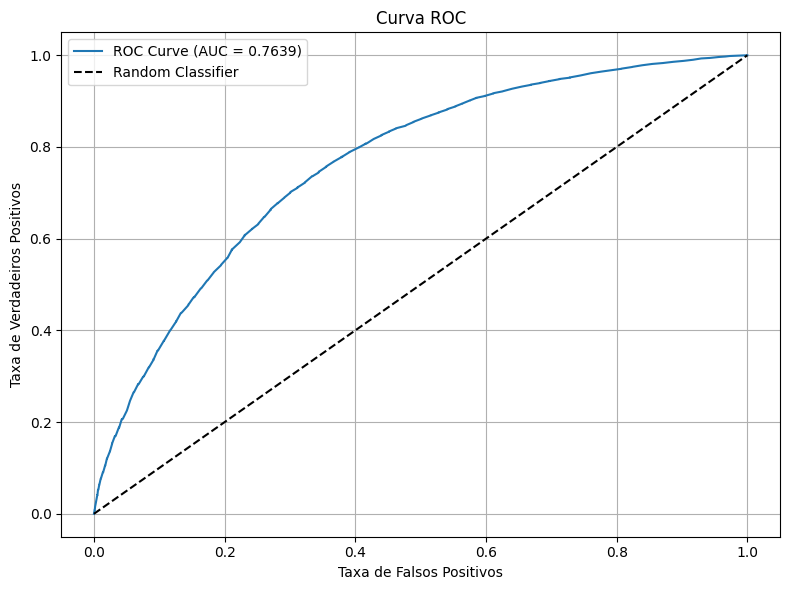

In [10]:
if len(np.unique(y_test)) == 2:
    from sklearn.metrics import roc_curve
    
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title('Curva ROC')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 6.1. Otimização de Hiperparâmetros

Otimização dos principais hiperparâmetros do Random Forest.

In [11]:
from sklearn.model_selection import RandomizedSearchCV

print("Otimizando hiperparâmetros do Random Forest...")
print("=" * 60)

param_distributions = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf_base, 
    param_distributions, 
    n_iter=20,
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

print(f"\nMelhores hiperparâmetros encontrados:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor score (ROC-AUC): {random_search.best_score_:.4f}")

Otimizando hiperparâmetros do Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores hiperparâmetros encontrados:
  n_estimators: 200
  min_samples_split: 5
  min_samples_leaf: 4
  max_depth: 20
  class_weight: None

Melhor score (ROC-AUC): 0.7837


In [12]:
print("Treinando modelo Random Forest otimizado...")
print("=" * 60)

model_optimized = random_search.best_estimator_

y_pred_opt = model_optimized.predict(X_test_scaled)
y_pred_proba_opt = model_optimized.predict_proba(X_test_scaled)[:, 1]

accuracy_opt = accuracy_score(y_test, y_pred_opt)
precision_opt = precision_score(y_test, y_pred_opt, average='weighted', zero_division=0)
recall_opt = recall_score(y_test, y_pred_opt, average='weighted', zero_division=0)
f1_opt = f1_score(y_test, y_pred_opt, average='weighted', zero_division=0)

print("MÉTRICAS DO MODELO OTIMIZADO:")
print(f"  Acurácia:  {accuracy_opt:.4f} ({accuracy_opt*100:.2f}%)")
print(f"  Precisão:  {precision_opt:.4f} ({precision_opt*100:.2f}%)")
print(f"  Recall:    {recall_opt:.4f} ({recall_opt*100:.2f}%)")
print(f"  F1-Score:  {f1_opt:.4f} ({f1_opt*100:.2f}%)")

if len(np.unique(y_test)) == 2:
    try:
        roc_auc_opt = roc_auc_score(y_test, y_pred_proba_opt)
        print(f"  ROC-AUC:   {roc_auc_opt:.4f} ({roc_auc_opt*100:.2f}%)")
    except:
        pass

Treinando modelo Random Forest otimizado...
MÉTRICAS DO MODELO OTIMIZADO:
  Acurácia:  0.7187 (71.87%)
  Precisão:  0.7222 (72.22%)
  Recall:    0.7187 (71.87%)
  F1-Score:  0.7151 (71.51%)
  ROC-AUC:   0.7850 (78.50%)


Top 10 Features Mais Importantes:
                feature  importance
32        REL_CONHECIDO    0.152390
30  REL_PARCEIRO_INTIMO    0.109170
16                SG_UF    0.071336
29             MES_OCOR    0.062740
0             AG_AMEACA    0.057534
36   CIRC_LESAO_FAMILIA    0.049945
28      DIA_SEMANA_OCOR    0.049942
24           VIOL_PSICO    0.046007
35         ESCOLARIDADE    0.041261
31         REL_FAMILIAR    0.040521


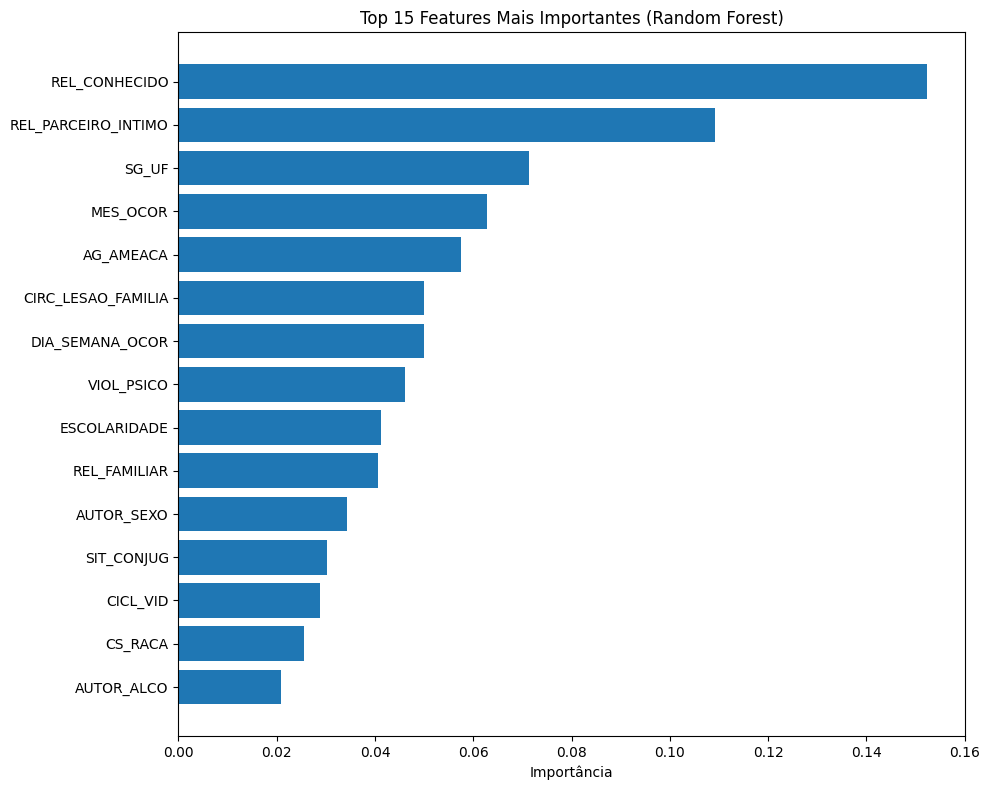

In [13]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_optimized.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Features Mais Importantes:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importância')
plt.title('Top 15 Features Mais Importantes (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()